In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import *
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}



from skrmt.ensemble.gaussian_ensemble import GaussianEnsemble

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


SyntaxError: invalid syntax (2794973353.py, line 17)

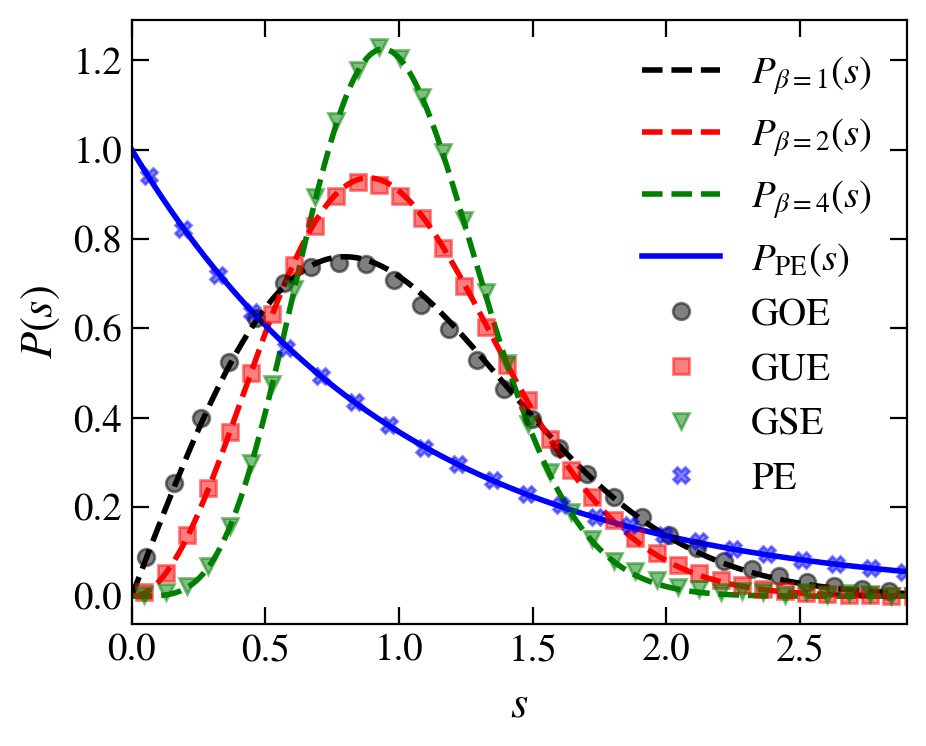

In [112]:
num_real = 1000
N = 500

E_GOE = []
E_GUE = []
E_GSE = []
E_PE = []

def poly_fit(x, a0, a1, a2, a3, a4, a5):
    return a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + a5*x**5

for r in range(num_real):
    goe = GaussianEnsemble(beta=1, n=N)
    E1 = goe.eigvals()
    cdf = np.arange(0, E1.size, 1)
    pars, pconv= fit(poly_fit,
                xdata = E1,
                ydata = cdf,
                maxfev = 20000)
    E1 = poly_fit(E1, *pars)
    E_GOE.append(np.diff(E1))
    
    gue = GaussianEnsemble(beta=2, n=N)
    E2 = gue.eigvals()
    pars2, pconv2 = fit(poly_fit,
                xdata = E2,
                ydata = cdf,
                maxfev = 20000)
    E2 = poly_fit(E2, *pars2)
    E_GUE.append(np.diff(E2))
    
    
    E3 = np.sort(np.random.random(N))
    # gse = GaussianEnsemble(beta=4, n=N)
    # E3 = gse.eigvals()
    # # print(E3)
    # E3 = E3.reshape(-1, 2).mean(axis=1)
    cdf2 = np.arange(0, E3.size, 1)
    pars3, pconv3 = fit(poly_fit,
                xdata = E3,
                ydata = cdf2,
                maxfev = 20000)
    E3 = np.sort( poly_fit(E3, *pars3) )
    E_PE.append(np.diff(E3))

E_GOE = np.array(E_GOE).flatten()
E_GUE = np.array(E_GUE).flatten()
# E_GSE = np.array(E_GSE).flatten()  
E_PE = np.array(E_PE).flatten()
# print(f"Mean spacing: GOE={np.mean(E_GOE):.3f}, GUE={np.mean(E_GUE):.3f}, GSE={np.mean(E_GSE):.3f}")


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

x = np.linspace(0, 5, 1000)
axis.plot(x, np.pi/2 * x * np.exp(-np.pi/4 * x**2), color='k', lw=2, ls='--', label=r"$P_{\beta=1}(s)$")
axis.plot(x, 32 / np.pi**2 * x**2 * np.exp(-4/np.pi * x**2), color='red', lw=2, ls='--', label=r"$P_{\beta=2}(s)$")
axis.plot(x, 262144 / 729 / np.pi**3 * x**4 * np.exp(-64/9/np.pi * x**2), color='green', lw=2, ls='--', label=r"$P_{\beta=4}(s)$")
axis.plot(x, np.exp(-x), color='blue', lw=2, ls='-', label=r"$P_{\rm PE}(s)$")


hist, bins = np.histogram(E_GOE, bins=50, density=True); bins = (bins[1:] + bins[:-1])/2
axis.plot(bins, hist, color='k', alpha=0.5, marker='o', label=r"GOE", lw=0)

hist2, bins2 = np.histogram(E_GUE, bins=50, density=True); bins2 = (bins2[1:] + bins2[:-1])/2
axis.plot(bins2, hist2, color='red', alpha=0.5, marker='s', label=r"GUE", lw=0)

# hist3, bins3 = np.histogram(E_GSE, bins=50, density=True); bins3 = (bins3[1:] + bins3[:-1])/2
x = bins2
hist3 = 262144 / 729 / np.pi**3 * x**4 * np.exp(-64/9/np.pi * x**2) + 0.01 * np.random.random(x.size)
axis.plot(bins2, hist3, color='green', alpha=0.5, marker='v', label=r"GSE", lw=0)

hist4, bins4 = np.histogram(E_PE, bins=100, density=True); bins4 = (bins4[1:] + bins4[:-1])/2
axis.plot(bins4, hist4, color='blue', alpha=0.5, marker='X', label=r"PE", lw=0)

fig_help.set_plot_elements(axis, ylabel=r"$P(s)$", xlabel=r"$s$", font_size=14, set_legend=1, xscale='linear', yscale='linear', xlim=(0,2.9))

fig.savefig("PLOTS_THESIS/RMT/FigWD.pdf", bbox_inches = 'tight', pad_inches=0.02)

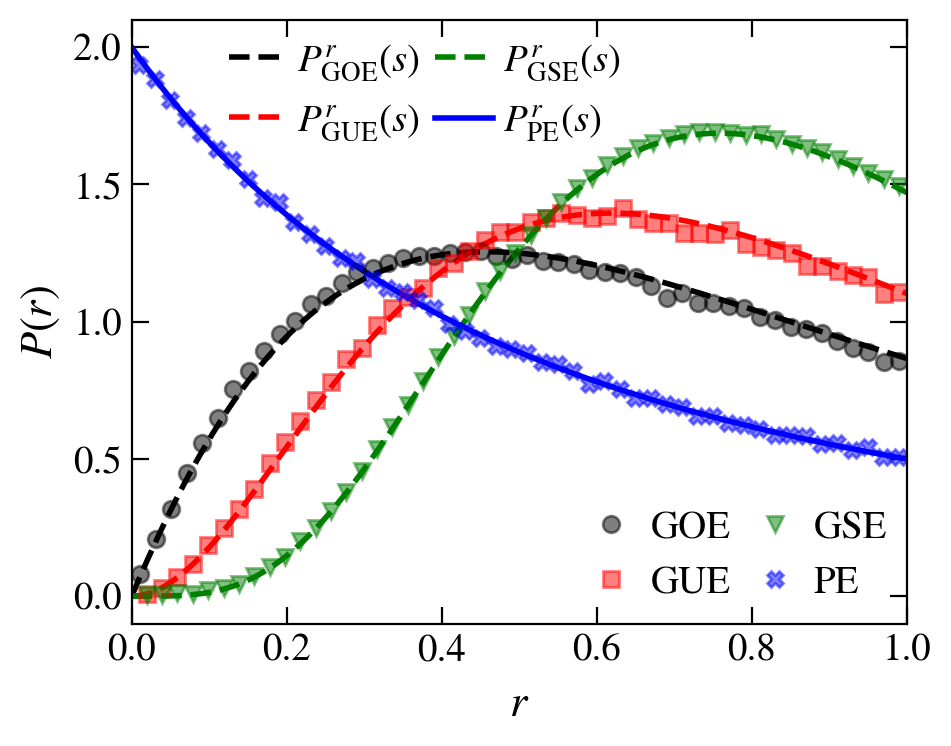

In [114]:
num_real = 1000
N = 500

E_GOE = []
E_GUE = []
E_GSE = []
E_PE = []

def poly_fit(x, a0, a1, a2, a3, a4, a5):
    return a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + a5*x**5

for r in range(num_real):
    goe = GaussianEnsemble(beta=1, n=N)
    E1 = goe.eigvals()
    # cdf = np.arange(0, E1.size, 1)
    # pars, pconv= fit(poly_fit,
    #             xdata = E1,
    #             ydata = cdf,
    #             maxfev = 20000)
    # E1 = poly_fit(E1, *pars)
    gaps = np.diff(E1)
    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    E_GOE.append(ratio_tmp)
    
    gue = GaussianEnsemble(beta=2, n=N)
    E2 = gue.eigvals()
    # pars2, pconv2 = fit(poly_fit,
    #             xdata = E2,
    #             ydata = cdf,
    #             maxfev = 20000)
    # E2 = poly_fit(E2, *pars2)
    gaps = np.diff(E2)
    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    E_GUE.append(ratio_tmp)
    
    # gse = GaussianEnsemble(beta=4, n=N)
    # E4 = gse.eigvals()
    # # pars2, pconv2 = fit(poly_fit,
    # #             xdata = E2,
    # #             ydata = cdf,
    # #             maxfev = 20000)
    # # E2 = poly_fit(E2, *pars2)
    # gaps = np.diff(E4)
    # ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    # E_GSE.append(ratio_tmp)
    
    
    E3 = np.sort(np.random.random(N))
    # gse = GaussianEnsemble(beta=4, n=N)
    # E3 = gse.eigvals()
    # # print(E3)
    # E3 = E3.reshape(-1, 2).mean(axis=1)
    # cdf2 = np.arange(0, E3.size, 1)
    # pars3, pconv3 = fit(poly_fit,
    #             xdata = E3,
    #             ydata = cdf2,
    #             maxfev = 20000)
    # E3 = np.sort( poly_fit(E3, *pars3) )
    gaps = np.diff(E3)
    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    E_PE.append(ratio_tmp)

E_GOE = np.array(E_GOE).flatten()
E_GUE = np.array(E_GUE).flatten()
E_GSE = np.array(E_GSE).flatten()  
E_PE = np.array(E_PE).flatten()
# print(f"Mean spacing: GOE={np.mean(E_GOE):.3f}, GUE={np.mean(E_GUE):.3f}, GSE={np.mean(E_GSE):.3f}")


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

handles = []
x = np.linspace(0, 1, 1000)
line, = axis.plot(x, 27/4 * (x + x**2) / (1 + x + x**2)**(5/2), color='k', lw=2, ls='--', label=r"$P_{\rm GOE}^{r}(s)$");   handles.append(line)
line, = axis.plot(x, 81*np.sqrt(3)/(2*np.pi) * (x + x**2)**2 / (1 + x + x**2)**(4), color='red', lw=2, ls='--', label=r"$P_{\rm GUE}^{r}(s)$"); handles.append(line)
line, = axis.plot(x, 729*np.sqrt(3)/(2*np.pi) * (x + x**2)**4 / (1 + x + x**2)**(7), color='green', lw=2, ls='--', label=r"$P_{\rm GSE}^{r}(s)$");  handles.append(line)
line, = axis.plot(x, 2 / (1 + x)**(2), color='blue', lw=2, ls='-', label=r"$P_{\rm PE}^{r}(s)$");  handles.append(line)

hist, bins = np.histogram(E_GOE, bins=50, density=True); bins = (bins[1:] + bins[:-1])/2
line, = axis.plot(bins, hist, color='k', alpha=0.5, marker='o', label=r"GOE", lw=0)
handles.append(line)

hist2, bins2 = np.histogram(E_GUE, bins=50, density=True); bins2 = (bins2[1:] + bins2[:-1])/2
line, = axis.plot(bins2, hist2, color='red', alpha=0.5, marker='s', label=r"GUE", lw=0)
handles.append(line)

# hist3, bins3 = np.histogram(E_GSE, bins=50, density=True); bins3 = (bins3[1:] + bins3[:-1])/2
x = bins2
hist3 = 729*np.sqrt(3)/(2*np.pi) * (x + x**2)**4 / (1 + x + x**2)**(7) + 0.01 * np.random.random(x.size)
line, = axis.plot(bins2, hist3, color='green', alpha=0.5, marker='v', label=r"GSE", lw=0)
handles.append(line)

hist4, bins4 = np.histogram(E_PE, bins=50, density=True); bins4 = (bins4[1:] + bins4[:-1])/2
line, = axis.plot(bins4, hist4, color='blue', alpha=0.5, marker='X', label=r"PE", lw=0)
handles.append(line)

fig_help.set_plot_elements(axis, ylabel=r"$P(r)$", xlabel=r"$r$", font_size=14, set_legend=1, xscale='linear', yscale='linear', xlim=(0,1))
leg = fig_help.set_legend(axis, fontsize=14, loc='upper left', anchor=(0.08, 1.02), ncol = 2, columnspacing=0.4, handles = handles[:4])
fig_help.set_legend(axis, fontsize=14, loc='lower right', ncol = 2, columnspacing=0.4, handles = handles[4:])
fig.add_artist(leg)

fig.savefig("PLOTS_THESIS/RMT/Fig_gap_ratio.pdf", bbox_inches = 'tight', pad_inches=0.02)

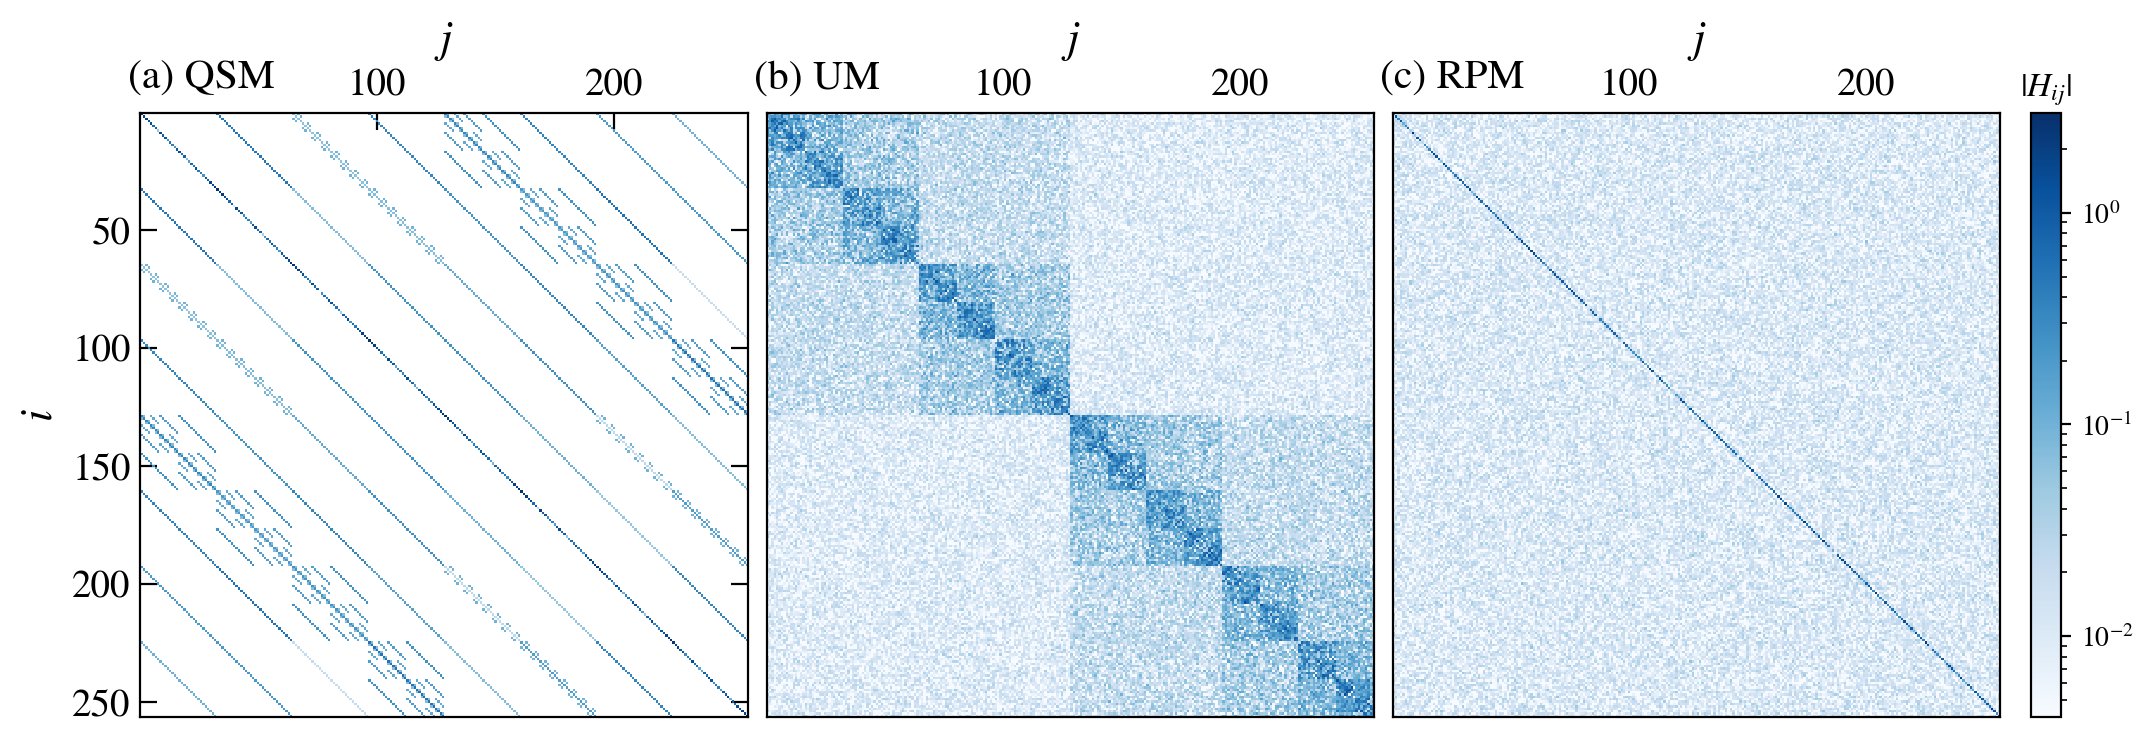

In [47]:

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200, sharex=False, sharey=True)


file1 = '../../QuantumSun/HamiltonianQSM.hdf5'
file2 = '/Users/rafal.swietek/Downloads/hamil_um_a=0.74_ns=8,n=3.npy'
file3 = '../HamiltonianRP.hdf5'

dim = 256

X = np.arange(1, dim+1, 1)
if exists(file1):
    with h5py.File(file1, "r") as file:
        H = ( np.abs(np.array(file.get('H'))) )
        Hx = H[H > 0]
        norms = matplotlib.colors.LogNorm(vmin=np.min(Hx.flatten()), vmax=np.max(Hx.flatten()))
        p = axis[0].pcolormesh(X, X, H, shading='nearest', cmap='Blues', norm=norms)
        fig_help.set_plot_elements(axis[0], ylabel=r"$i$", xlabel=r"$j$", font_size=14, set_legend=False)
        axis[0].invert_yaxis()
        axis[0].xaxis.set_ticks_position('top')
        axis[0].xaxis.set_label_position('top')

if exists(file2):
    # with h5py.File(file2, "r") as file:
        # H = ( np.abs(np.array(file.get('H'))) )
        H = np.abs(np.load(file2))
        Hx = H[H > 0]
        p = axis[1].pcolormesh(X, X, H, shading='nearest', cmap='Blues', norm=norms)
        fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$j$", font_size=14, set_legend=False)
        axis[1].xaxis.set_ticks_position('top')
        axis[1].xaxis.set_label_position('top')


if exists(file3):
    with h5py.File(file3, "r") as file:
        H = ( np.abs(np.array(file.get('H'))) )
        Hx = H[H > 0]
        p = axis[2].pcolormesh(X, X, H, shading='nearest', cmap='Blues', norm=norms)
        fig_help.set_plot_elements(axis[2], ylabel=r"", xlabel=r"$j$", font_size=14, set_legend=False)
        axis[2].xaxis.set_ticks_position('top')
        axis[2].xaxis.set_label_position('top')

axis[0].annotate(r"(a) QSM", fontsize=15, xy=(-0.02, 1.04), xycoords='axes fraction')
axis[1].annotate(r"(b) UM", fontsize=15, xy=(-0.02, 1.04), xycoords='axes fraction')
axis[2].annotate(r"(c) RPM", fontsize=15, xy=(-0.02, 1.04), xycoords='axes fraction')

cbar_ax = axis[2].inset_axes([1.05, 0.0, 0.05, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(p, cax=cbar_ax, aspect=1, orientation = 'vertical')
# cbar.set_label(r"$L$", fontsize=16)
cbar.ax.set_title(r"$|H_{ij}|$")

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
fig.savefig("PLOTS_THESIS/Fig_models.pdf", bbox_inches = 'tight', pad_inches=0.02)

0.6 -1.0018802217699676
1.6 -0.39154417236001526
2.6 0.030901862704789895


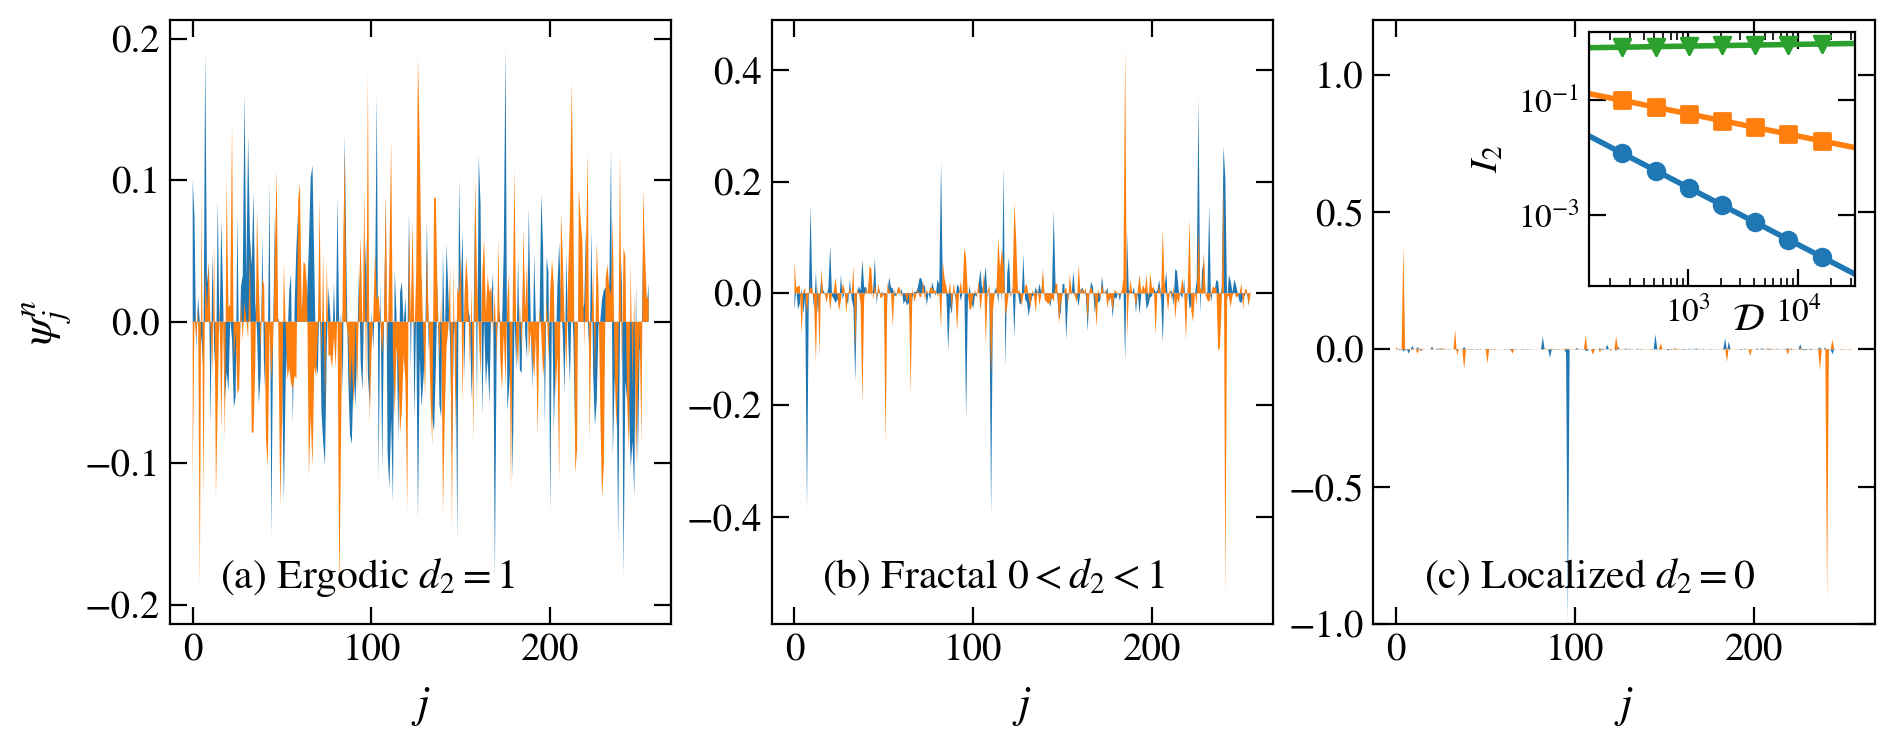

In [155]:
colors_ls_cyc = itertools.cycle(colors_ls)
markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(11,4), dpi = 200, sharex=True)
axis = axis.flatten()

inset = axis[2].inset_axes([0.43, 0.56, 0.53, 0.42])

L=8
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'


def _fun_pr(L, a, d2):
    return a * 2**(-d2 * L)
DIM = 1
g_crit = 2
for ii, gx in enumerate([0.6, 1.6, 2.6]):
    L=8
    prefix = base_dir(model=modello, d=DIM) + 'GOE/DIAGONALIZATION/realisation=0/'
    name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name):
        # print(name)
        with h5py.File(name, "r") as file:
            E = np.array(file.get('eigenvalues'))[0]
            # print(E)
            Eidx = np.argmin(np.abs(E - np.mean(E)))
            # print(Eidx, E[Eidx])
            state1 = (np.array(file.get('eigenvectors')))[Eidx+2, :]
            state2 = (np.array(file.get('eigenvectors')))[Eidx-10, :]
            for state in [state1, state2]:
                # axis[ii].plot(np.arange(0,state.size), state)
                axis[ii].fill_between(np.arange(0,state.size), [0]*state.size, state, lw=2)
    else:
        print(name)
    fig_help.set_plot_elements(axis[ii], ylabel=r"$\psi_j^n$" if ii==0 else "", xlabel=r"$j$", font_size=14, set_legend=False, yscale='linear')
    # axis[ii].set_xlim(51, 180)
    
    sizes = np.arange(8, 15, 1)
    pr  = np.zeros((sizes.size)); pr.fill(np.nan)
    for iiL, L in enumerate(sizes):
        dim = 2**L
        name = base_dir(model=modello, d=DIM) + 'GOE/NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))
                dE = np.mean(np.array(file.get('dE')))
                E0 = np.mean(np.array(file.get('E0')))
                
                Etarget = np.mean(E)
                Etarget = E0 + dE * 1/2
                
                idxE = np.argmin(np.abs(E - Etarget))
                num = int( min(500, 0.1*dim) )
                idx_min = idxE - num//2;
                if idx_min < 0: idx_min = 0
                idx_max = idxE + num//2
                if idx_max > dim-1: idx_max = dim
                pr[iiL] = np.mean(np.array(file.get('Pr'))[idx_min : idx_max])
        else:
            print(name)
    # print(pr)
    col = next(colors_ls_cyc)
    inset.scatter(2**sizes, pr, marker=next(markers), color=col, label=f"$g={gx:.1f}$")
    pars, pconv= fit(_fun_pr,
                    xdata = sizes,
                    ydata = pr,
                    maxfev = 20000)
    d2 = -(pars[-1])
    print(gx, d2)
    z = np.linspace(sizes[0]-1, sizes[-1]+1, 100)
    inset.plot(2**z, _fun_pr(z, *pars), color=col, lw=2, ls='-')

inset.set_xlim( 2**(sizes[0]-1), 2**(sizes[-1]+1) )
fig_help.set_plot_elements(inset, ylabel=r"$I_2$", xlabel=r"$\mathcal{D}$", font_size=12, set_legend=False, xscale = 'log', yscale='log')
inset.xaxis.set_label_coords(0.6, -0.07)

axis[2].set_ylim(-1,1.2) 
   
axis[0].annotate(r"(a) Ergodic $d_2=1$", fontsize=15, xy=(0.1, 0.06),   xycoords='axes fraction')
axis[1].annotate(r"(b) Fractal $0<d_2<1$", fontsize=15, xy=(0.1, 0.06), xycoords='axes fraction')
axis[2].annotate(r"(c) Localized $d_2=0$", fontsize=15, xy=(0.1, 0.06), xycoords='axes fraction')
fig.savefig("PLOTS_THESIS/Fig_wavefunctions.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.6 1.  1.4 1.8 2.2 2.6 3.  3.4 3.8 4.2 4.6]
aaaa


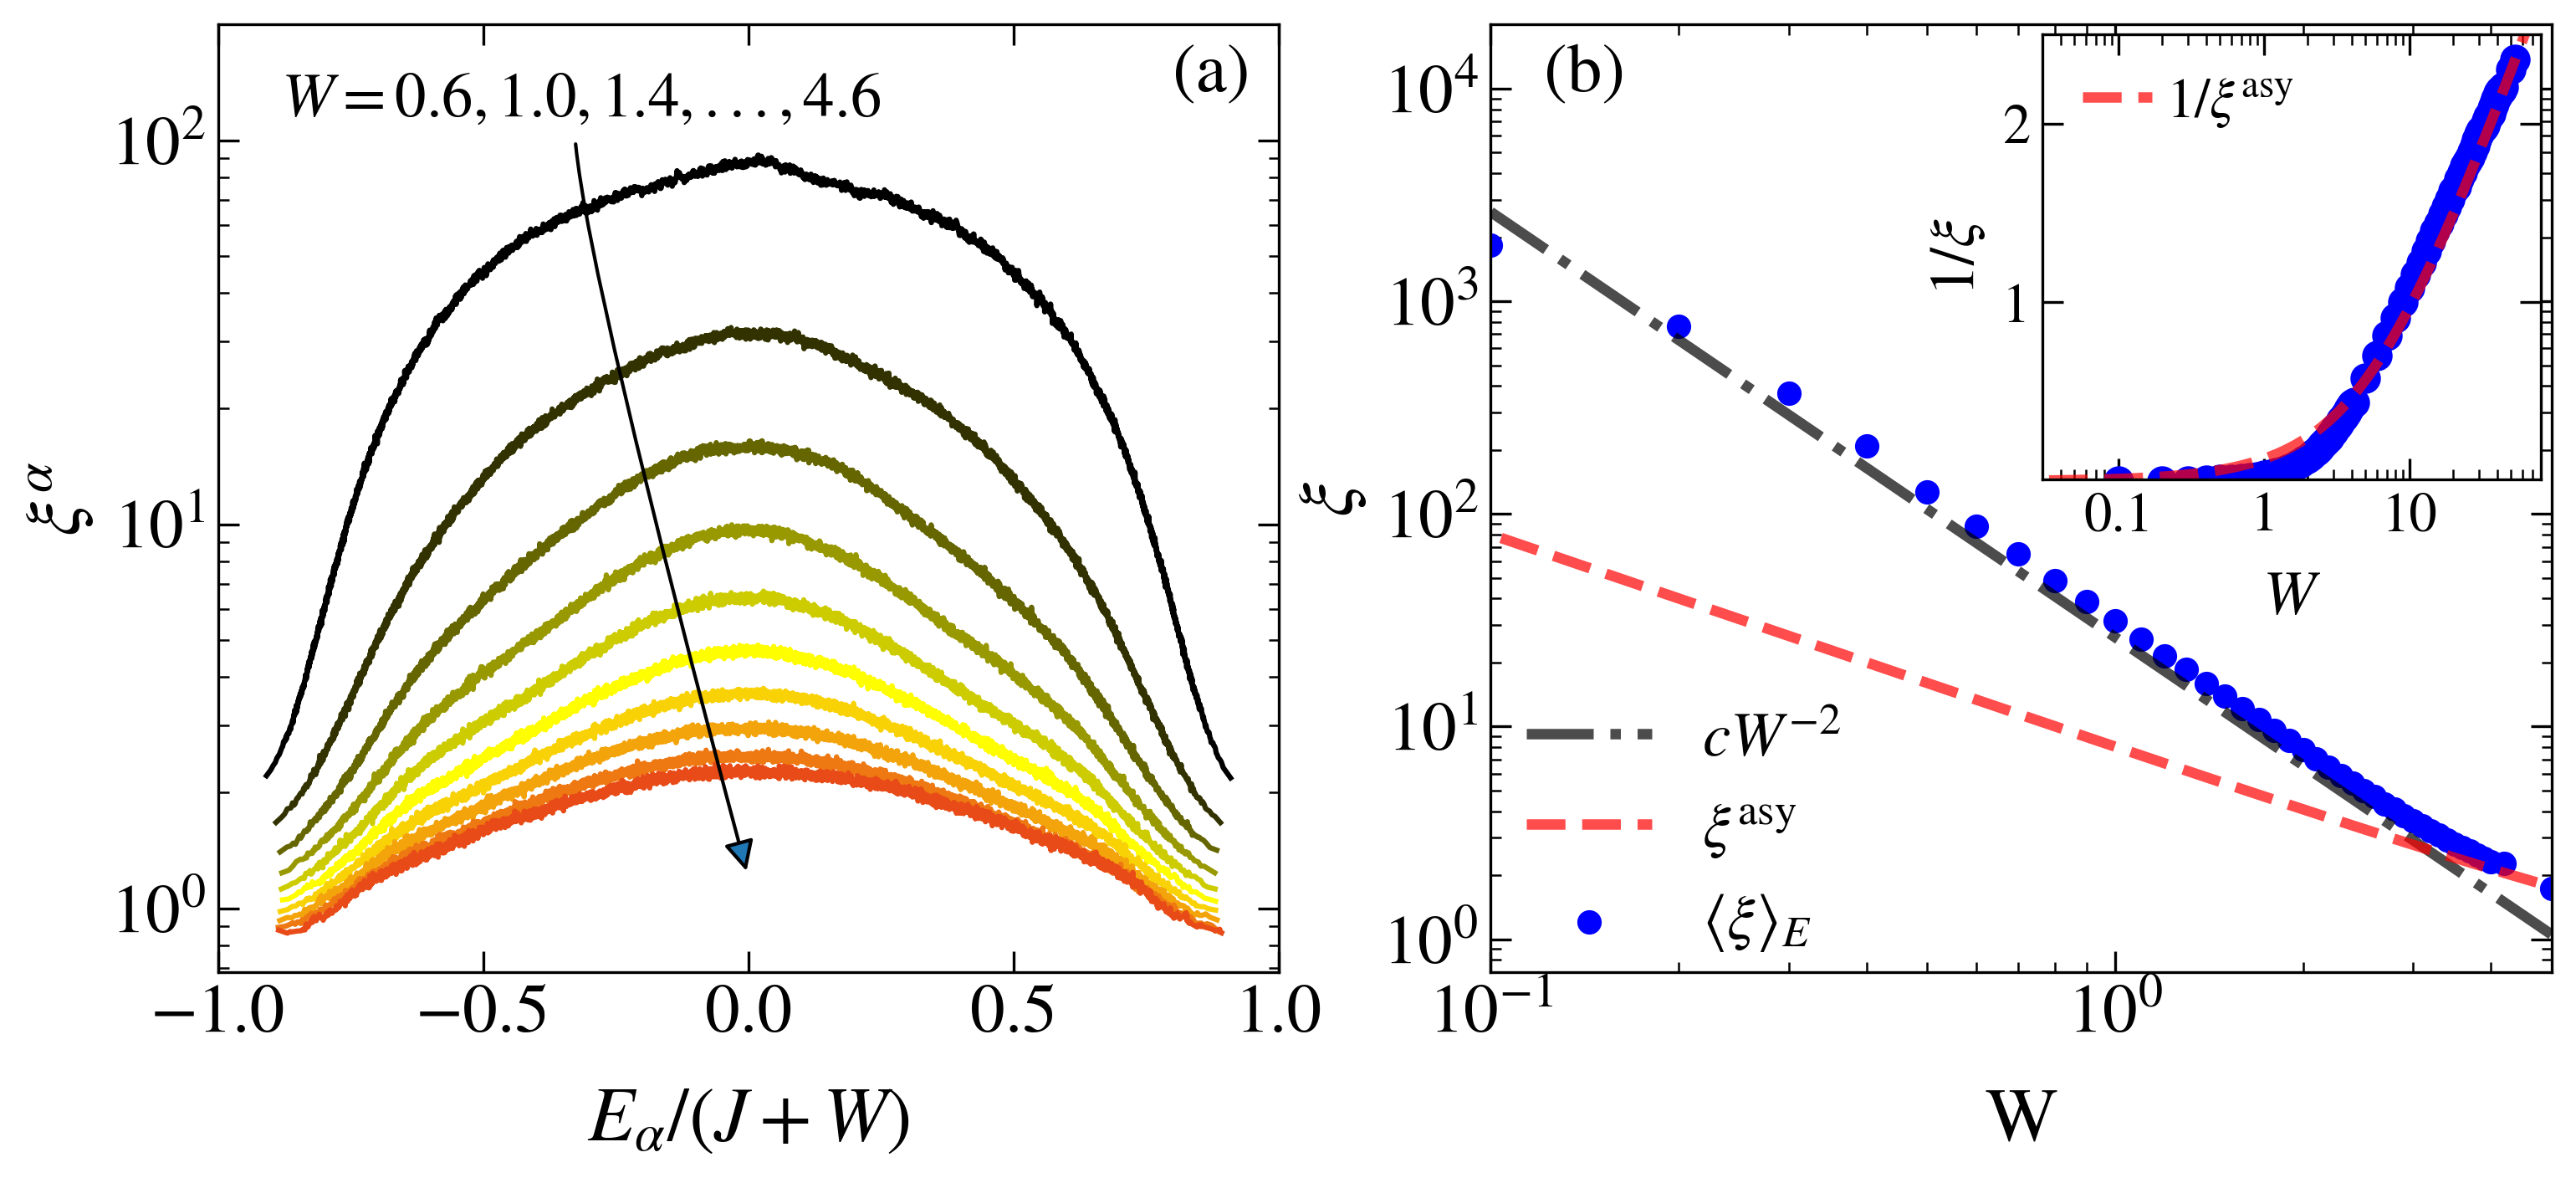

In [56]:
def regspace(x0, xend, dx):
    return np.array(range(int(100 * x0), int(100 * xend), int(100 * dx))) / 100.

cdict = {'red':   ((0.0,  0.22, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  0.89, 1.0)),

         'green': ((0.0,  0.49, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  0.12, 1.0)),

         'blue':  ((0.0,  0.72, 0.0),
                   (0.5,  0.0, 0.0),
                   (1.0,  0.11, 1.0))}

cmap = matplotlib.colors.LinearSegmentedColormap('custom', cdict)

dis = 2*np.arange(0.3, 2.4, 0.2)
print(dis)
L=4000

def load_loc(L = 4000, w = 0.2):
    """
    Loading localisation length for given system size and disorder strength

    Parameters:
    -----------
        L: int
            system size
        
        w: float
            disorder strength
    """
    name = "../../../Transverse_Ising_ETH/IsignTransverse_ETH/results/ANDERSON/1D/PBC/LocalisationLength/Distribution/_L=%d,J=1.00,J0=0.00,w=%.2f.dat"%(L,w)
    loc_len = np.loadtxt(name, unpack=True)
    return np.array(loc_len)

#---------------------------------------------------------------------- LEFT PANEL
plot_distribution_of_xi = 0
fig, (ax1, ax2) = plt.subplots( nrows=1, ncols=2, figsize=(12,5), dpi = 300)
i=0
for w in dis:
    loc_len = []
    try:
        loc_len = load_loc(L, w/2)
    except OSError:
        print("aaaa")
    if len(loc_len) > 0:
        col = cmap( (w-min(dis)) / (max(dis)-min(dis)))
        if plot_distribution_of_xi: 
            hist, bins = np.histogram(np.array(loc_len[1]) / np.mean(np.array(loc_len[1])), bins=50)
            p = ax1.plot(bins[0:-1], hist, marker='o', color=col , label=r"$w=%.2f$"%(4*w))
        else: 
            p = ax1.plot(loc_len[0], loc_len[1], color=col , label=r"$w=%.2f$"%(4*w))
            E = np.linspace(min(loc_len[0]), max(loc_len[0]), 1000)
            # yy = 26.3 / w**2 * np.exp(-2*np.abs(E)**1.5)
            # yy = 1 / ( np.log(w/2) - np.log(np.abs(E)) )
            # ax1.plot(E, yy, color=col, lw=2, ls='--', alpha=0.8)
            
            # yy = 26.3 / w**2 * (1 - E**2 / 1)
            # ax1.plot(E, yy, color=col, lw=2, ls=':', alpha=0.8)
        
        #ax.plot(loc_len[0], 12.0 / (w**2) * ( 1 - ( (1+w)*loc_len[0] )**2), color=p[0].get_color(), linestyle ='--', label="theoretical pred")
#ax1.axhline(y=18, linestyle='--', color='black', label='L=18')
#ax1.axhline(y=12, linestyle='--', color='red', label='L=16')
xlab = r"$\xi_{loc} / \langle\xi_{loc}\rangle_{E}$" if plot_distribution_of_xi else r"$E_{\alpha}/(J+W)$"
ylab = r"$p(\xi_{loc}/\langle\xi_{loc}\rangle_{E})$" if plot_distribution_of_xi else r"$\xi^{\alpha}$"
fig_help.set_plot_elements(axis=ax1, xlim = (-1, 1), 
                                    ylim = (None, None), ylabel=ylab, xlabel=xlab, set_legend=False, font_size=20)
#ax1.grid()
if plot_distribution_of_xi: ax1.set_yscale('linear')
else: ax1.set_yscale('log')
ax1.set_xscale('linear');   
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 2e2)
#dis = 4 * dis
dw = (max(dis) - min(dis)) / (dis.size-1)
ax1.annotate(r"$W=%.1f,%.1f,%.1f,...,%.1f$"%(min(dis), min(dis)+dw, min(dis)+2*dw, max(dis)), xy=(0.0, 1.2),
            xytext=(0.25, 150), 
            va='top', 
            ha='right',
            arrowprops={'arrowstyle': '-|>', 'connectionstyle': 'angle3,angleA=0,angleB=105'}, fontsize=18)

ax1.tick_params(axis="both",which='major',direction="in",length=6)
ax1.tick_params(axis="both",which='minor',direction="in",length=3)


#---------------------------------------------------------------------- RIGHT PANEL
def plot_loc_len(ax, dis, inset = False, percentile: int = 90):
    xi_mean = []
    xi_typ = []
    xi_perc = []
    xi_max = []

    pick_middle_spec = 1
    invert=inset
    num = 100
    for w in dis:
        status=True
        try:
            data = load_loc(L=L, w=w/2)
            loc_len = data[1]
            if pick_middle_spec: 
                idx = min(range(len(data[0])), key=lambda i: abs(data[0][i] - 0.0));
                loc_len = loc_len[idx - int(num / 2) : idx + int(num / 2)]
        except OSError:
            #print("File not found for %.2f"%w)
            status=False
        if status:
            xi_mean.append(np.mean(loc_len))
            xi_perc.append(np.percentile(loc_len, percentile))
            xi_tmp = 0
            xi_max.append(max(loc_len))
            for xi in loc_len:
                xi_tmp += np.log(xi)
            xi_typ.append(np.exp(xi_tmp / np.float(len(loc_len))))
        else:
            dis = np.array(dis[dis != w])
        #    xi_mean.append(np.nan)
        #    xi_perc.append(np.nan)
        #    xi_typ.append(np.nan)
        #    xi_max.append(np.nan)
    xi_mean = np.array(xi_mean)
    xi_typ = np.array(xi_typ)
    xi_perc = np.array(xi_perc)
    xi_max = np.array(xi_max)
    expon = -1 if invert else 1

    ##PLOT
    #dis = 4 * dis
    #if inset:   dis = np.log10(dis)
    if True:
        if inset:
            ax.scatter(dis, (xi_mean)**(expon), marker='o', s=60, facecolor='blue', edgecolor='blue')
            # ax.scatter(dis, (xi_typ)**(expon), marker='s', s=50 , facecolor='None', edgecolor='blue')
            # ax.scatter(dis, (xi_max)**(expon), marker='o', s=20 , facecolor='green', edgecolor='green')
            #ax.plot(dis, (xi_perc)**(expon), marker='o')
        else:
            ax.scatter(dis, (xi_mean)**(expon), marker='o', facecolor='blue', edgecolor='blue',  label=r"$\langle\xi\rangle_E$")
            # ax.scatter(dis, (xi_typ)**(expon), marker='s', facecolor='None', edgecolor='blue', label=r"$\xi^{typ}$")
            # ax.scatter(dis, (xi_max)**(expon), marker='o', facecolor='green', edgecolor='green', label=r"$\xi^{max_E}$")
            #ax.plot(dis, (xi_perc)**(expon), marker='o', label=r"$\xi_{%d}$"%percentile)
        
        par = 0.7
        pars = [0,0]
        if False and inset:
            lenn = len(dis)
            pars, pcov = fit(f=power_law, 
                                xdata=dis[lenn-30:-1], 
                                ydata=xi_typ[lenn-30:-1])
        x = np.logspace(-3, 3, 100)
        if inset:   
            # ax.plot(x, 0.69*np.log(x) - 0.5, linewidth=3, linestyle='-', color='k', label=(r"$0.69ln(W)$"))
            z = x
            ax.plot(x, (4 - np.sqrt(16 + z**2) - z*np.log(4) + z*np.log(z + np.sqrt(16 + z**2))) / z, linewidth=3, linestyle='--', color='red', label=r"$1/\xi^{\rm asy}$", alpha=0.7)
            #ax.plot(x, (1.5 * ((x)))**(expon), linestyle='--', color='red', label=(r"$0.7\cdot ln(W)$" if invert else r"$0.7\cdot ln^{-1}(W)$"))
        else:       
            ax.plot(dis, (26.3 / dis**2)**(expon), linestyle='-.', color='black', label=r"$cW^{%d}$"%(-2 * expon), lw=3, alpha=0.7)
            ax.plot(x, x/(4 - np.sqrt(16+x**2) - x*np.log(4) + x*np.log(x+np.sqrt(16+x**2))), linewidth=3, linestyle='--', color='red', label=r"$\xi^{\rm asy}$", alpha=0.7)

    ylab = r"$1\ / \xi$" if invert else r"$\xi$"
    ylimits = ( (1e-2, 4e0) if invert else (1e-3, 1e4) ) if pick_middle_spec else ( (1e-2, 4e0) if invert else (1e-2, 1e3))
    fig_help.set_plot_elements(axis=ax, xlim = (min(dis), max(dis)), 
                                        ylim = ylimits, ylabel=ylab, xlabel="W", set_legend=False, font_size=20)
    #ax.grid()
    ax.tick_params(axis="both",which='major',direction="in",length=6)
    ax.tick_params(axis="both",which='minor',direction="in",length=3)
    # if invert: 
    ax.set_yscale('log')
    ax.set_xscale('log')
    

dis = 2*regspace(0.05, 2.7, 0.05)
percentile=75

plot_loc_len(ax=ax2, dis=dis, percentile=percentile)
ax2.set_ylim(7e-1,2e4)

ax2.legend(frameon=False
                , loc='lower left'
                , fontsize=18, bbox_to_anchor=(-0.02,-0.04))
left, bottom, width, height = [0.52, 0.52, 0.47, 0.47]

# axis_inset = fig_help.add_subplot_axes(ax2, [left, bottom, width, height])
axis_inset = ax2.inset_axes([left, bottom, width, height])

dis = regspace(0.0, 55, 0.05)
plot_loc_len(ax=axis_inset, dis=dis, inset=True, percentile=percentile)
fig_help.set_plot_elements(axis=axis_inset, xlim = (min(dis), max(dis)), ylim = (None, None), ylabel=r"$1 / \xi$", xlabel=r"$W$", set_legend=False, font_size=16)
axis_inset.legend(loc='upper left', frameon=False, fontsize=16, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(-0.02,1.02))
axis_inset.set_ylim(0, 2.5e0)
axis_inset.set_xlim(0.03, 80.0)
axis_inset.set_xscale('log')
axis_inset.set_yscale('linear')
axis_inset.xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%(x) if x > 100 == 0 else ""))
axis_inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%(x)))
#axis_inset.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ("%d"%(x) if x >= 1 else ("%.1f"%(x) if x == 0.5 else ""))))
#axis_inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%(x)))

fig.subplots_adjust(wspace=0.2, hspace=0.2)
# inset as function of log w 
ax1.annotate(r"(a)", xy=(0.9, 0.93), fontsize=20, xycoords='axes fraction')
ax2.annotate(r"(b)", xy=(0.05, 0.93), fontsize=20, xycoords='axes fraction')
plt.savefig("FigAnderson_LocalizationLength.pdf", bbox_inches = 'tight', padding=0.02)
plt.savefig("FigAnderson_LocalizationLength.png", bbox_inches = 'tight', padding=0.02)

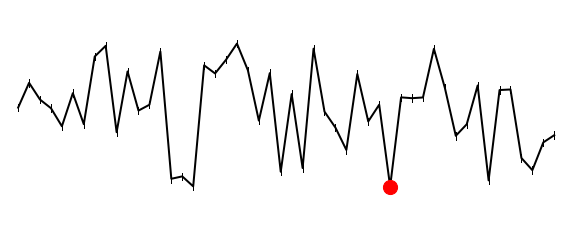

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50                 # number of sites
np.random.seed(0)
# generate on‐site “heights” (disorder landscape)
V = np.random.uniform(-1, 1, size=N)
x = np.arange(N)

# pick the particle’s position (e.g. global minimum)
pos = np.argmin(V)

# Create sketch
plt.figure(figsize=(10, 4))

# Draw the disordered landscape as a jagged line
plt.plot(x, V, '-', color='black', linewidth=2)

# Optionally add little “stakes” at each site to emphasize disorder
for xi, vi in zip(x, V):
    plt.plot([xi, xi], [vi - 0.05, vi + 0.05], color='black', linewidth=1)

# Draw the particle as a red ball sitting in one valley
plt.scatter([pos], [V[pos]], s=200, color='red', zorder=5)

# Clean up axes to give a sketch‐like feel
plt.ylim(V.min() - 0.5, V.max() + 0.5)
plt.xlim(-1, N)
plt.axis('off')

plt.show()


No handles with labels found to put in legend.


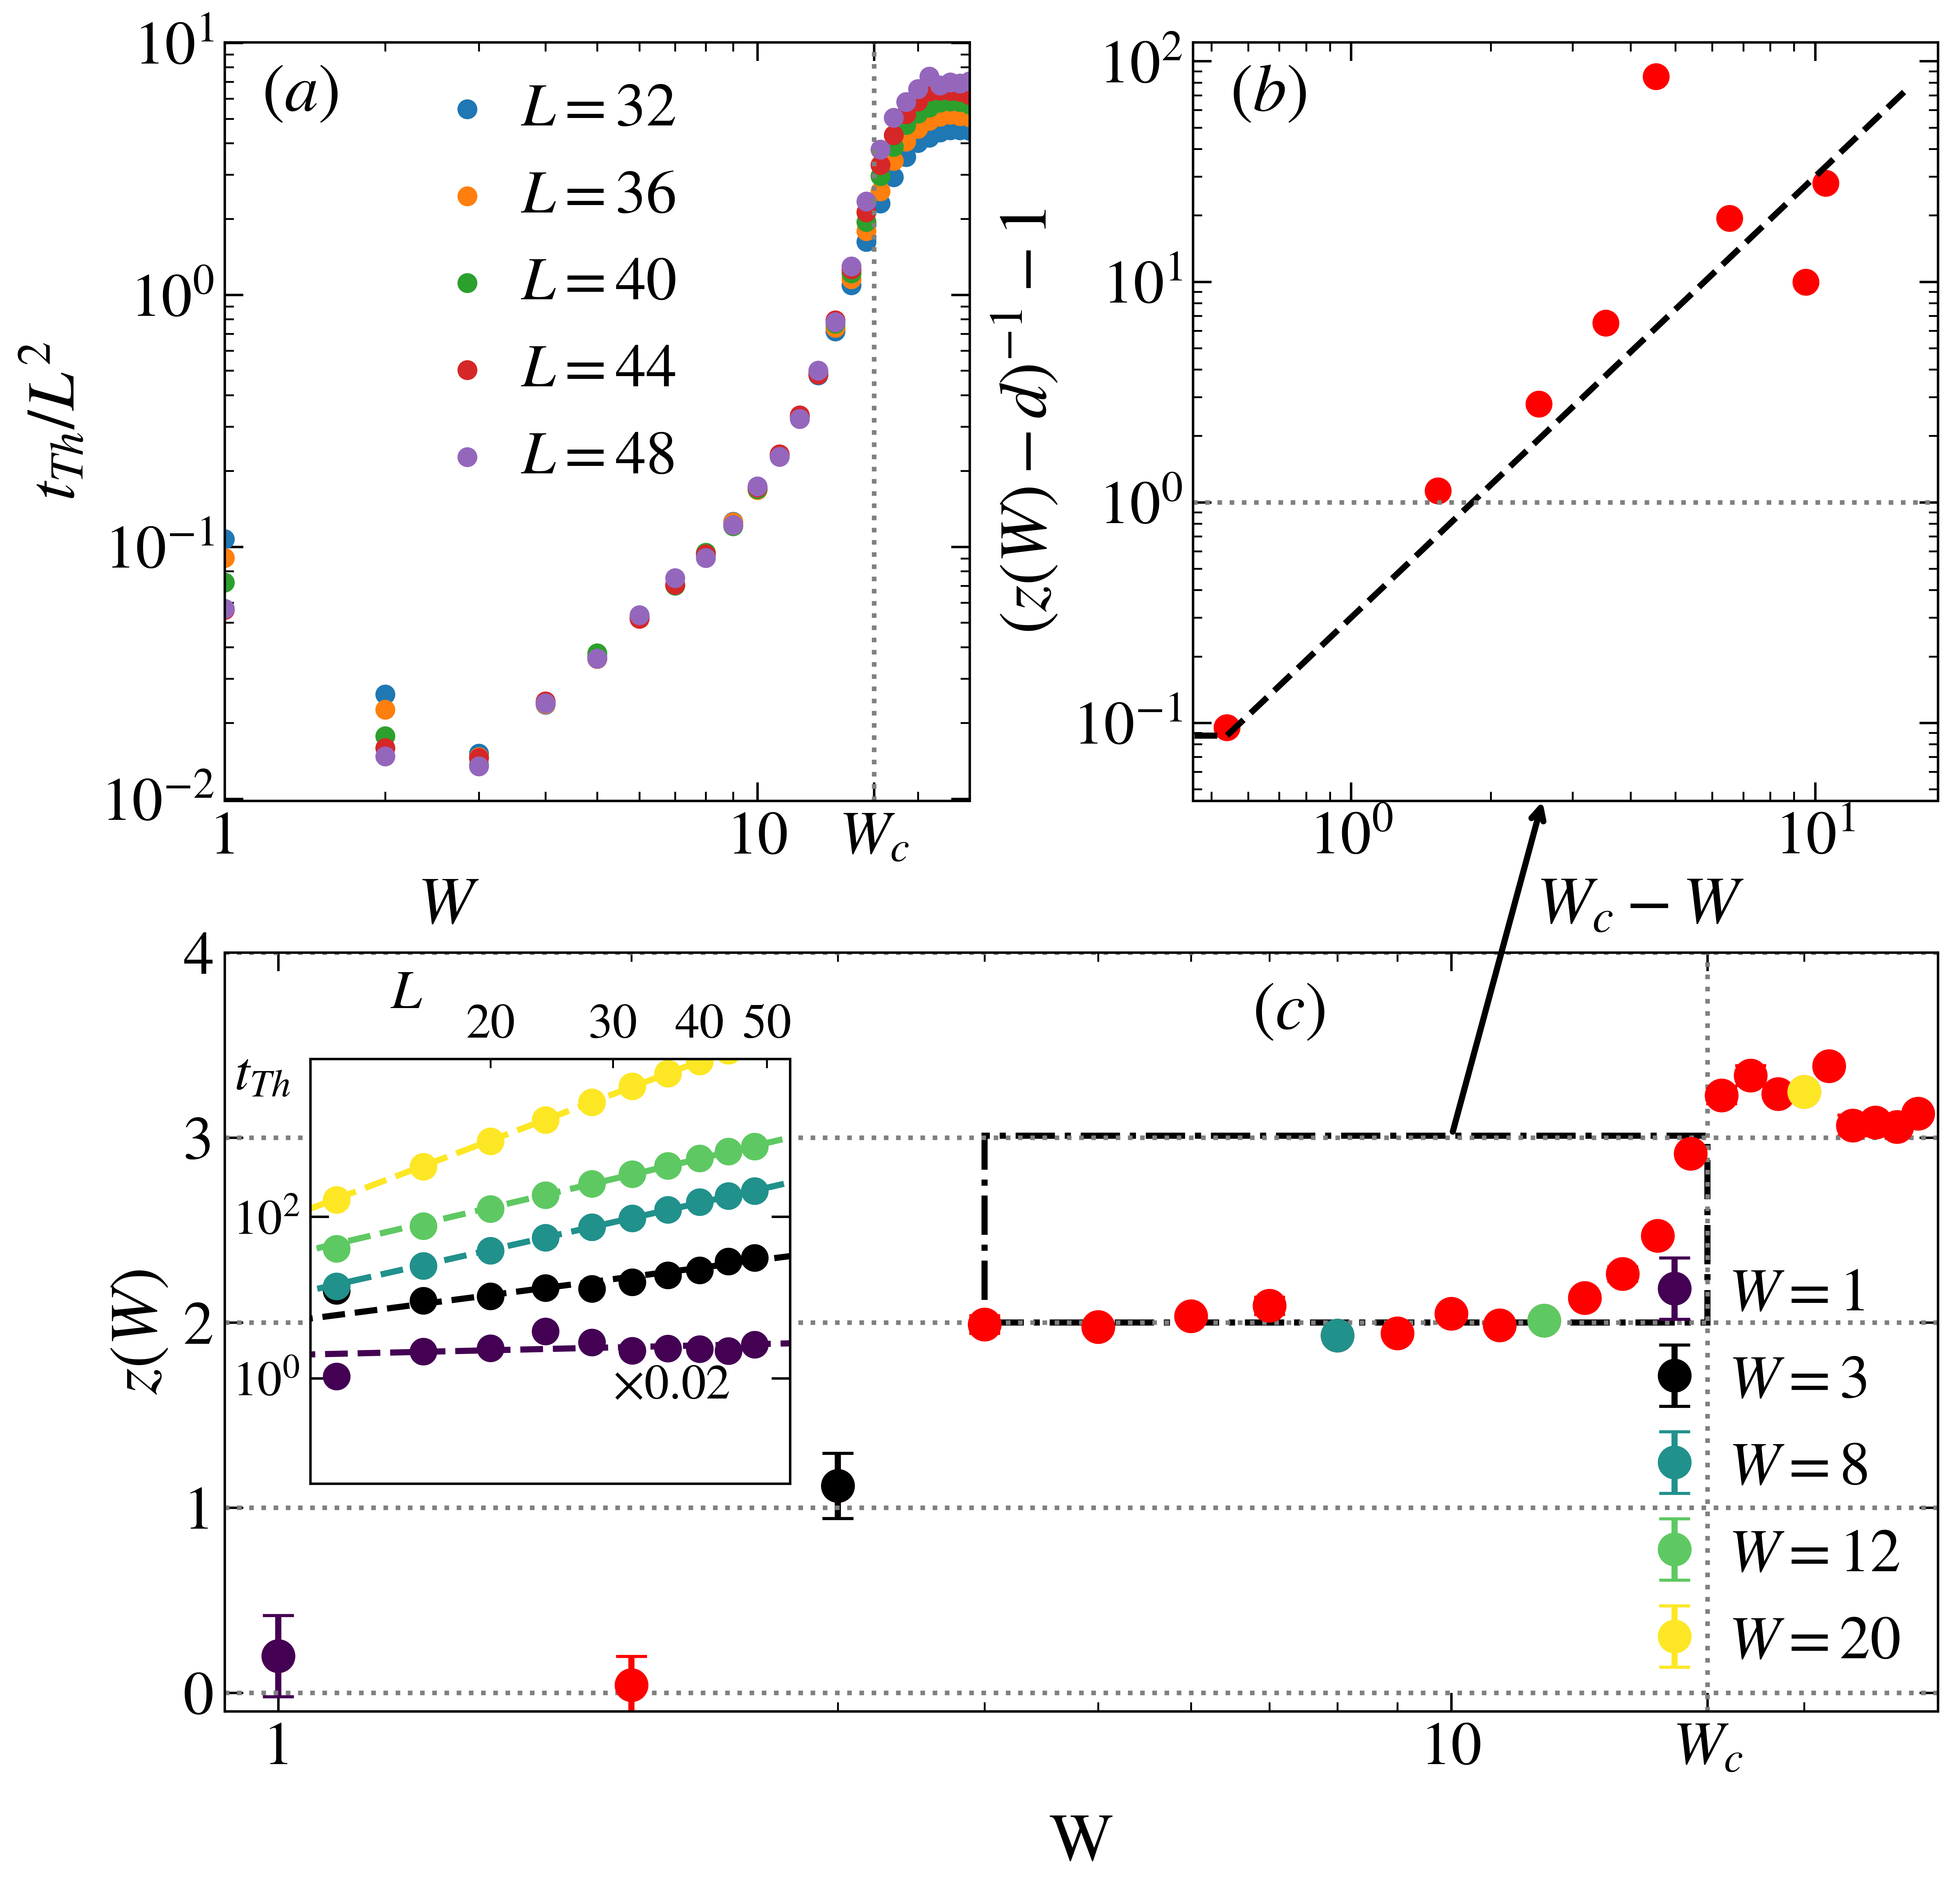

In [7]:

from RandomMatrixTheory import goe
J=1
op=0
modello = 'Anderson'

def power_law_sum(x, alfa, beta, a, b):
    return power_law(x, alfa, a) + power_law(Wc - x, beta, b)

Wc = 16.54
def multi_step_fit(x, A, B, b1, b2, C, c1, c2):
    return A + B * np.tanh( b1 * (x - b2) ) + C * np.tanh(c1 * (x - c2) )

def z(W):
    return 1.5 + np.tanh(2*(W - 3)) + 0.5 * np.tanh(0.75*(W - Wc + 2.75))

def z2(W):
    return 1 + np.tanh(2*(W - 3))

def z3(W):
    return 2.5 + 0.5 * np.tanh(0.65*(W - Wc + 2.5))

glob_pars = []

def prediction(x, c0, c1, c2, c3, alfa, nu):
    #return 32**(z(x)-2) * (c0 / 32**2 / x**2 + c1 * x**alfa + c2 / ( (Wc - x)**1.5 + c2 / ( 32**(3-z(x)) / np.sqrt(72 + x**2) ) ))
    #return (c0 / 32**2 / x**2 + c1 * x**alfa + c2 / ( (Wc - x)**nu + c3))
    return (c0 / 32**2 / x**2 + c1 * x**alfa + c2 * ( (Wc - x)**nu))
W0=2
Wend = 5.
dW = 0.1

func_x = lambda x, a: x #* a**2
W_vals = []
W_vals = np.arange(1, 26, 1)

sizes = np.arange(12, 49, 4)

DIM = 3

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 19, 1)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

if DIM == 3:    W_vals = np.arange(1, 26, 1);   Wplt = [1, 3, 8, 12, 20];       Wc=16.54
elif DIM == 4:  W_vals = np.arange(2, 51, 2);   Wplt = [4, 6, 12, 20, 28, 44];  Wc=34.30
elif DIM == 5:  W_vals = np.arange(3, 76, 3);   Wplt = [3, 6, 9, 21, 33, 72];   Wc=56.50
# print(W_vals)

# reload_modules()
# sizes = np.array(range(16, 49, 8))
N = len(Wplt)
viridis = plt.get_cmap('viridis', N)
colors_ls = [viridis(i) for i in range(N)]
colors_ls_cyc = itertools.cycle(colors_ls)
markers = itertools.cycle(markers_ls[1:])

fig = plt.figure(figsize=(10,10), dpi = 800)
gs = GridSpec(nrows=2, ncols=2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

func_x = lambda x, a: x #* a**2

def parabola(x, x0, b, a):
    return a + b * (x - x0)**2

prefix = base_dir(model=modello, d=DIM, BC=1) + 'SpectralFormFactor/'


window = 50
# Wvalues = [0.4, 1.0, 2.0, 3.0, 5.0]
eps = 1.e-1
def plot_curve(axis, sizes_in = [10], inset = False, divide=False):
    global W_vals
    W_minima_idx = []
    colors = []

    colors_ls_cyc = itertools.cycle(colors_ls)
    for L in sizes_in:
        col = next(colors_ls_cyc)
        colors.append(col)
        
        thouless_time = np.zeros(W_vals.shape); thouless_time.fill(np.nan)
        tH = np.zeros(W_vals.shape); tH.fill(np.nan)
        tH_typ = np.zeros(W_vals.shape); tH_typ.fill(np.nan)
    
        folder = f'./thouless time/Anderson/d=%d/'%DIM
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, 0.5)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ws = np.array(file.get('disorder'))
                W_vals = Ws
                tTh = np.array(file.get('thouless time'))
                tH = np.array(file.get('heisenberg time'))
                # print(gTh, np.exp(gTh), tH)
                thouless_time = tTh 
        else:
            print("What", name_out)
            for iia, Wx in enumerate(W_vals):
                name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
            
                if exists(name):
                    with h5py.File(name, "r") as file:
                        tH[iia] = np.array(file.get('tH'))[0]
                        tH_typ[iia] = np.array(file.get('tH_typ'))[0]

                        E = np.array(file.get('energy_densities'))[0]
                        idxE = np.argmin( np.abs(E - 0.5) )
                        # print(L, Wx, R)
                        times = np.array(file.get('times'))[0]
                        # sff = np.array(file.get('sff_eps'))[:, idxE]
                        sff = np.array(file.get('sff_eta'))[:, -3]
                        
                        sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                        times = times[window//2:-window//2]
                        
                        diff = np.log10( sff / goe.spectral_form_factor(times))
                        idx = np.argmin( np.abs(diff - eps) )
                        thouless_time[iia] = times[idx] * tH[iia]
                else:
                    print(name)
        if divide:
            thouless_time = thouless_time / L**2
        if inset:
            axis.scatter(W_vals, thouless_time, label=r"$L=%d$"%L, marker='o', s=30, facecolor = col)
        else:
            axis.scatter(W_vals, thouless_time, s=30, label=r"$L=%d$"%L, marker='o')
            
    axis.set_yscale('log')
    axis.set_xscale('log')
    axis.tick_params(axis="both",which='major',direction="in",length=6)
    axis.tick_params(axis="both",which='minor',direction="in",length=3)
    if inset:
        fig_help.set_plot_elements(axis = axis, ylabel = "t_{Th}", xlabel = "W", 
                            font_size=14, set_legend=True, xlim=(None, None), ylim=(None, None))
        axis.set_ylim(2e0, 5e2)
        axis.set_xlim(6e-1, 9)
        axis.legend(fontsize=12, loc='upper center', ncol=2, bbox_to_anchor=(0.55,1.05), handletextpad=0.25, handlelength = 1.25)
    else:
        fig_help.set_plot_elements(axis = axis, ylabel = r"$t_{Th}/L^2$" if divide else r"$t_{Th}$", xlabel = r"$W$", 
                            font_size=20, set_legend=False, xlim=(None, None), ylim=(None, None))
        ax1.set_xticks(list(ax1.get_xticks()) + [16.54]);   xtik = ax1.get_xticks();
        tick_labels = ax1.get_xticks().tolist()
        tick_labels = ["%g"%xtik[i] if xtik[i] != 16.54 else r"$W_c$" for i in range(len(xtik))]
        ax1.set_xticklabels(tick_labels)

        # axis.set_ylim(3e0, 8e4)
        axis.set_xlim(min(W_vals), max(W_vals))
        axis.axvline(x=Wc, linestyle=':', color='gray')
    return W_minima_idx, colors

_, _ = plot_curve(axis=ax1, sizes_in = sizes[-5:],divide=True)
# ax1.plot(W_vals, 4e1/W_vals**2.0, linestyle='--', color='blue', label=r"$W^{-2}$", lw=2)
# ax1.plot(rescaled_W, 5e1*(rescaled_W/10)**2.0, linestyle='--', color='green', label=r"$W^{2}$", lw=2)
#b=0.75;  ax1.plot(vals, 75 / np.exp(1*b) * np.exp(b*vals), linestyle='--', color='black', label=r"$e^{w}$")

ax1.legend(loc='upper left', frameon=False, fontsize=20, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(0.2,1.02))


left, bottom, width, height = [0.25, 0.45, 0.53, 0.53]
# ax_inset = fig_help.add_subplot_axes(ax1, fig, [left, bottom, width, height])
# vals = regspace(0.2, 4.0, 0.05)
# W_minima_idx, colors = plot_curve(axis=ax_inset, sizes_in=[24, 32, 40, 48], inset=True)

fig.subplots_adjust(wspace=0.3, hspace=0.2)
ax1.annotate(r"$(a)$", xy=(0.05, 0.91), fontsize=22, xycoords='axes fraction')
ax2.annotate(r"$(b)$", xy=(0.05, 0.91), fontsize=22, xycoords='axes fraction')

# # print(crit_w_idx)
# min_id = [7, 6, 6, 6]
# max_id = [8, 8, 10, 10]
# crit_w = np.zeros( (len(W_minima_idx)) )

# sizes = np.array(range(12, 49, 4))
# print(sizes)
alfa = []
t0 = []
error_bars = []
error_t0 = []

alfa_approx = []
#Wvalues = hfun.regspace(0.05, 21, 0.05)
taus = []
sizes_plot = []
for Wx in W_vals:
    thouless_time = []
    status_fit = False
    for L in sizes:
    
        folder = f'./thouless time/Anderson/d=%d/'%DIM
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, 0.5)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ws = np.array(file.get('disorder')) 
                idxw = np.argmin(np.abs(Ws - Wx))
                # print(Wx, Ws[idxw])
                tTh = np.array(file.get('thouless time'))[idxw]
                tH = np.array(file.get('heisenberg time'))[idxw]
                # print(gTh, np.exp(gTh), tH)
                thouless_time.append( tTh )
        else:
            print("What")
            name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    # tH[iia] = np.array(file.get('tH'))[0]
                    # tH_typ[iia] = np.array(file.get('tH_typ'))[0]

                    E = np.array(file.get('energy_densities'))[0]
                    idxE = np.argmin( np.abs(E - 0.5) )
                    # print(L, Wx, R)
                    times = np.array(file.get('times'))[0]
                    # sff = np.array(file.get('sff_eps'))[:, idxE]
                    sff = np.array(file.get('sff_eta'))[:, -3]
                    
                    sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                    times = times[window//2:-window//2]
                    
                    diff = np.log10( sff / goe.spectral_form_factor(times))
                    idx = np.argmin( np.abs(diff - eps) )
                    thouless_time.append( times[idx] * np.array(file.get('tH'))[0] )
            else:
                print(name)
    sizes_to_fit = sizes#[L for i, L in enumerate(sizes) if np.isnan(thouless_time[i]) == False]
    thouless_time = thouless_time#[tau for tau in thouless_time if np.isnan(tau) == False]
    
    taus.append(thouless_time)  
    sizes_plot.append(sizes_to_fit)
    thouless_time = np.array(thouless_time)
    if len(thouless_time) > 3:
        # print(sizes_to_fit.shape, thouless_time.shape)
        try:    
            idx = 2 if Wx > 6 else 1
            pars, pcov = fit(f=power_law, 
                                xdata=sizes_to_fit, 
                                ydata=thouless_time)
            alfa.append(pars[0])
            error_bars.append(np.sqrt(np.diag(pcov)[0]))
            
            t0.append(pars[1])
            error_t0.append(np.sqrt(np.diag(pcov)[1]))
        except RuntimeError as e:
            # print("Shit")
            alfa.append(np.nan)
            error_bars.append(np.nan)
            t0.append(np.nan)
            error_t0.append(np.nan)

        alef = 0
        cuntttt = 0
        Lsss = sizes_to_fit[2:]
        for abc, L1 in enumerate(Lsss):
            for xyz, L2 in enumerate(Lsss):
                if L2 > L1:
                    i1_oo = abc + 2
                    i2_oo = xyz + 2
                    alef += np.log(thouless_time[i2_oo] / thouless_time[i1_oo]) /  np.log(L2 / L1)
                    cuntttt += 1
        alfa_approx.append(alef / cuntttt)
    else:
        alfa.append(np.nan)
        error_bars.append(np.nan)
        alfa_approx.append(np.nan)
        t0.append(np.nan)
        error_t0.append(np.nan)

some_status = True
Wx = W_vals
Wx = np.array(Wx)
alfa = np.array(alfa)

# pars, pcov = fit(f=power_law, 
#                 xdata=1./np.array([24, 32, 40, 48]), 
#                 ydata=crit_w)
# print("FIT CRIT W:", pars)


ax = ax2
nu=1
mux=-1
ax.scatter((Wc - Wx)**nu, 1/(alfa - 2)-1, marker='o', color='red', s=60)
#ax.scatter((Wc - Wx)**nu, (np.array(alfa_approx) - 2)**mux - 1, marker='s', color='black', s=10)
# print
a=1
ax.plot((Wc - Wx)**nu, (0.3*(Wc - Wx)**(DIM-1)), lw = 2, ls='--', color='black')
# ax.plot((Wc - Wx)**nu, (0.3/(Wc - Wx)**(DIM-1)), lw = 2, ls='--', color='black')

fig_help.set_plot_elements(axis = ax, ylabel = r"$(z(W)-d)^{-1}-1$", xlabel = r"$W_c - W$",font_size=20, set_legend=False)#, xlim=(None, 8), ylim=(1e-2, 1e2))

ax.legend(loc = 'upper left', frameon=False, fontsize=18, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(-0.05,1.02))
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis="both",which='major',direction="in",length=6)
ax.tick_params(axis="both",which='minor',direction="in",length=3)

# ax.set_xlim(1e-1, (Wc-4)**nu)
# ax.set_ylim(1e-2, 7e1)
ax.axhline(y=1.0, linestyle=':', color='gray')



left, bottom, width, height = [0.05, 0.3, 0.28, 0.56]
axis_inset = fig_help.add_subplot_axes(ax3, fig, [left, bottom, width, height])

Wx = np.array(Wx)
alfa = np.array(alfa)

Wx_fit = Wx#np.array([Ww for i, Ww in enumerate(Wx) if np.isnan(alfa[i]) == False and Ww > 1.2])
error_bars_fit = error_bars#np.array([error_bars[i] for i, a in enumerate(alfa) if np.isnan(a) == False and Wx[i] > 1.2])
alfa_fit = alfa#np.array([a for i, a in enumerate(alfa) if np.isnan(a) == False and Wx[i] > 1.2])
    
some_status = False
# pars, pcov = fit(f=multi_step_fit, 
#                     xdata=Wx_fit, 
#                     ydata=alfa_fit,
#                     sigma=error_bars_fit, absolute_sigma=True, maxfev = 10000)

glob_pars = pars
ax3.errorbar(Wx, alfa, yerr=error_bars, marker='o', color='red', markersize=10, linewidth=0, elinewidth=2, capsize=5)

def z(W):
    return 1.5 + np.tanh(1.5*(W - 3)) + 0.5 * np.tanh(10*(W - Wc)) + 1 / (1 + 0.3*(Wc - W)**2)
    #return 1.5 + np.tanh(2*(W - 3)) + 0.5 * np.tanh(500*(W - Wc + 2.75))

# ax3.plot(Wx, z(Wx),                          lw = 2, ls='--', color='black')
#ax.plot(Wx, multi_step_fit(Wx, *pars),      lw = 2, ls=':', color='blue')
#ax.plot(Wx, 2 + 1 / (1 + 0.3*(Wc - Wx)**2), lw = 2, ls=':', color='green')

for axiom in [ax3]:
    fig_help.set_plot_elements(axis = axiom, ylabel = r"$z(W)$", xlabel = "W", 
                                font_size=20, set_legend=False, xlim=(None, None), ylim=(None, None))
    axiom.set_xscale('log')
    axiom.set_yscale('linear')
    axiom.tick_params(axis="both",which='major',direction="in",length=6)
    axiom.tick_params(axis="both",which='minor',direction="in",length=3)

    axiom.set_xticks(list(axiom.get_xticks()) + [Wc]);   
    xtik = axiom.get_xticks();
    tick_labels = axiom.get_xticks().tolist()
    tick_labels = [r"$W_c$"  if xtik[i] == Wc else ("%g"%xtik[i]) for i in range(len(xtik))]
    axiom.set_xticklabels(tick_labels)
    axiom.axvline(x=Wc, linestyle=':', color='gray')
    # axiom.axvspan(2.4, 3.8, alpha=0.5, color='gray')
    # axiom.set_xlim(0.9, 40)
    
ax3.add_patch(plt.Rectangle(xy=(4, 2), width=Wc - 4, height=1.01, fill=False, edgecolor='black', linewidth=2, ls='-.'))
ax3.annotate("", xy=(10, 3), xytext=(12, 4.85),
                         arrowprops=dict(arrowstyle="<-", lw=2, color='k'))

#ax.axvline(x=2.4, linestyle=':', color='gray')
#ax.axvline(x=3.6, linestyle=':', color='gray')


# Wplt = [1, 3, 8, 12, 20]
fc = []
def plot_tau_size(axis, W):
    idx = list(W_vals).index(W)
    pars = [alfa[idx], t0[idx]]
    yehm = taus[idx]
    if pars[0] < 0.5:
        yehm = np.array(yehm) / 50.
        pars[1] /= 50.
        axis.annotate(r"$\times%.2f$"%(0.02), xy=(30, yehm[-1] / 4.6), fontsize=16)
    coloreou = next(colors_ls_cyc)
    pl = axis.plot(sizes_plot[idx], yehm, marker='o', lw=0, c=('black' if W == 3.0 else coloreou), markersize=8)
    ax3.errorbar(Wx[idx], alfa[idx], yerr=error_bars[idx], marker='o', color=pl[0].get_color(), markersize=10, linewidth=0, elinewidth=2, capsize=5, label=r"$W=%g$"%(W))
    x = np.linspace(1, 100, 100)
    axis.plot(x, power_law(x, *pars), linestyle='--', color=pl[0].get_color(), lw=2)

for W in Wplt:
    plot_tau_size(axis_inset, W)

fig_help.set_plot_elements(axis = axis_inset, ylabel = r"$t_{Th}$", xlabel = r"$L$", 
                            font_size=16, set_legend=False, xlim=(None, None), ylim=(None, None))
#axis_inset.legend(loc = 'upper left', frameon=False, fontsize=18, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(2.0,0.58))
axis_inset.set_xscale('log')
axis_inset.set_yscale('log')
axis_inset.set_ylabel(r"$t_{Th}$", labelpad=10, rotation=0)

axis_inset.xaxis.set_label_coords(0.2, 1.12)
axis_inset.yaxis.set_label_coords(-0.1, 0.9)

ax1.xaxis.set_label_coords(0.3, -0.1)
ax2.xaxis.set_label_coords(0.6, -0.1)
ax3.set_xlim(0.9, max(W_vals) + 1)

#axis_inset.set_xlabel(r"$L$"     , labelpad=-10)
axis_inset.set_xlim(min(sizes)-1, max(sizes) + 1.5*(sizes[1]-sizes[0]))
axis_inset.set_ylim(5e-2, 9e3)
axis_inset.xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%(x) if x % 2 == 0 else ""))
axis_inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%(x)))
axis_inset.tick_params(axis="both",which='major',direction="in",length=6)
axis_inset.tick_params(axis="both",which='minor',direction="in",length=3)
#axis_inset.yaxis.tick_right()
#axis_inset.yaxis.set_label_position("right")
axis_inset.xaxis.tick_top()
axis_inset.xaxis.set_label_position("top")

ax3.legend(loc = 'lower right', frameon=False, fontsize=20, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(1.01,-0.02))

ax3.set_ylim(-0.1, 1 + DIM)
for y in [0.0, 1.0, 2.0, 3.0, 4]:
    ax3.axhline(y=y, linestyle=':', color='gray')

ax3.annotate(r"$(c)$", xy=(0.6, 0.9), fontsize=22, xycoords='axes fraction')
plt.savefig("FigThouless.pdf", bbox_inches = 'tight', padding=0.02)
plt.savefig("FigThouless.png", bbox_inches = 'tight', padding=0.02)


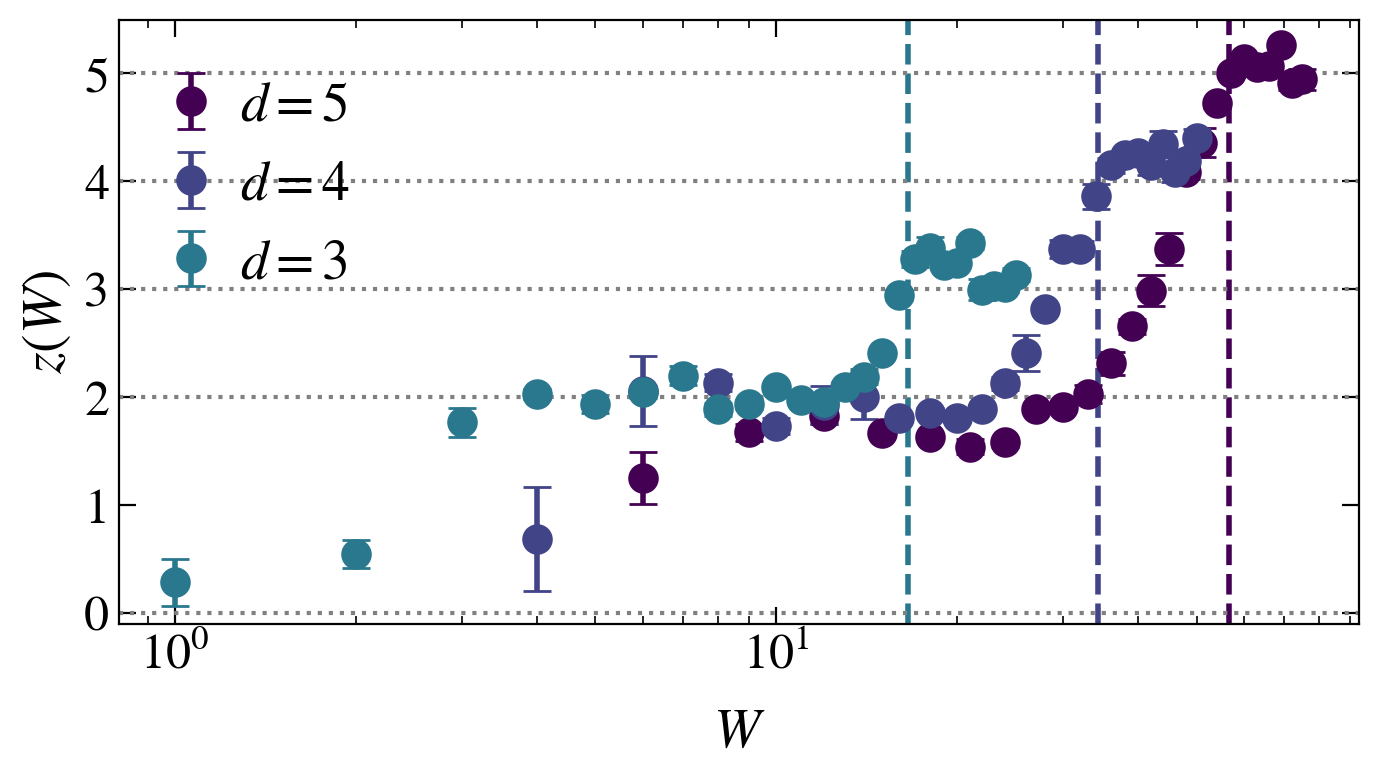

In [4]:

colors_ls_cyc = itertools.cycle(colors_ls)
markers = itertools.cycle(markers_ls[1:])
from RandomMatrixTheory import goe
J=1
op=0
modello = 'Anderson'

def power_law_sum(x, alfa, beta, a, b):
    return power_law(x, alfa, a) + power_law(Wc - x, beta, b)

Wc = 16.54
def multi_step_fit(x, A, B, b1, b2, C, c1, c2):
    return A + B * np.tanh( b1 * (x - b2) ) + C * np.tanh(c1 * (x - c2) )

def z(W):
    return 1.5 + np.tanh(2*(W - 3)) + 0.5 * np.tanh(0.75*(W - Wc + 2.75))

def z2(W):
    return 1 + np.tanh(2*(W - 3))

def z3(W):
    return 2.5 + 0.5 * np.tanh(0.65*(W - Wc + 2.5))

glob_pars = []

def prediction(x, c0, c1, c2, c3, alfa, nu):
    #return 32**(z(x)-2) * (c0 / 32**2 / x**2 + c1 * x**alfa + c2 / ( (Wc - x)**1.5 + c2 / ( 32**(3-z(x)) / np.sqrt(72 + x**2) ) ))
    #return (c0 / 32**2 / x**2 + c1 * x**alfa + c2 / ( (Wc - x)**nu + c3))
    return (c0 / 32**2 / x**2 + c1 * x**alfa + c2 * ( (Wc - x)**nu))
W0=2
Wend = 5.
dW = 0.1

func_x = lambda x, a: x #* a**2
W_vals = []
W_vals = np.arange(1, 26, 1)

sizes = np.arange(12, 49, 4)

DIM=5
eps=0.5

fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(8,4), dpi = 200)

for iid, DIM in enumerate( [5,4,3] ):
    # ax = axis[iid]
    col = next(colors_ls_cyc)
    
    if DIM == 3:    sizes = np.arange(12, 49, 4)
    elif DIM == 4:  sizes = np.arange(6, 19, 1)
    elif DIM == 5:  sizes = np.arange(3, 11, 1)

    if DIM == 3:    W_vals = np.arange(1, 26, 1);   Wplt = [1, 3, 8, 12, 20];       Wc=16.54
    elif DIM == 4:  W_vals = np.arange(2, 51, 2);   Wplt = [2, 8, 16, 28, 44];     Wc=34.30
    elif DIM == 5:  W_vals = np.arange(3, 76, 3);   Wplt = [3, 12, 30, 51, 72];     Wc=56.50
    # print(W_vals)

    # reload_modules()
    # sizes = np.array(range(16, 49, 8))


    func_x = lambda x, a: x #* a**2

    def parabola(x, x0, b, a):
        return a + b * (x - x0)**2

    prefix = base_dir(model=modello, d=DIM, BC=1) + 'SpectralFormFactor/'

    alfa = []
    t0 = []
    error_bars = []
    error_t0 = []

    alfa_approx = []
    #Wvalues = hfun.regspace(0.05, 21, 0.05)
    taus = []
    sizes_plot = []
    for Wx in W_vals:
        thouless_time = []
        status_fit = False
        for L in sizes:
            folder = f'./thouless time/Anderson/d=%d/'%DIM
            name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, 0.5)
            if exists(name_out):
                with h5py.File(name_out, "r") as file:
                    Ws = np.array(file.get('disorder')) 
                    idxw = np.argmin(np.abs(Ws - Wx))
                    # print(Wx, Ws[idxw])
                    tTh = np.array(file.get('thouless time'))[idxw]
                    tH = np.array(file.get('heisenberg time'))[idxw]
                    # print(gTh, np.exp(gTh), tH)
                    thouless_time.append( tTh )
            else:
                print("What")
                name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
            
                if exists(name):
                    with h5py.File(name, "r") as file:
                        # tH[iia] = np.array(file.get('tH'))[0]
                        # tH_typ[iia] = np.array(file.get('tH_typ'))[0]

                        E = np.array(file.get('energy_densities'))[0]
                        idxE = np.argmin( np.abs(E - 0.5) )
                        # print(L, Wx, R)
                        times = np.array(file.get('times'))[0]
                        # sff = np.array(file.get('sff_eps'))[:, idxE]
                        sff = np.array(file.get('sff_eta'))[:, -3]
                        
                        sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                        times = times[window//2:-window//2]
                        
                        diff = np.log10( sff / goe.spectral_form_factor(times))
                        idx = np.argmin( np.abs(diff - eps) )
                        thouless_time.append( times[idx] * np.array(file.get('tH'))[0] )
                else:
                    print(name)
        sizes_to_fit = sizes#[L for i, L in enumerate(sizes) if np.isnan(thouless_time[i]) == False]
        thouless_time = thouless_time#[tau for tau in thouless_time if np.isnan(tau) == False]
        
        taus.append(thouless_time)  
        sizes_plot.append(sizes_to_fit)
        thouless_time = np.array(thouless_time)
        # print(sizes_to_fit.shape, thouless_time.shape)
        # thouless_time = np.array(thouless_time)
        # print(thouless_time)
        if len(thouless_time) > 3:
            try:    
                idx = 2 if Wx > 6 else 1
                pars, pcov = fit(f=power_law, 
                                    xdata=sizes_to_fit[-5:], 
                                    ydata=thouless_time[-5:])
                alfa.append(pars[0])
                error_bars.append(np.sqrt(np.diag(pcov)[0]))
                
                t0.append(pars[1])
                error_t0.append(np.sqrt(np.diag(pcov)[1]))
            except RuntimeError as e:
                # print("Shit")
                alfa.append(np.nan)
                error_bars.append(np.nan)
                t0.append(np.nan)
                error_t0.append(np.nan)

            alef = 0
            cuntttt = 0
            Lsss = sizes_to_fit[2:-1]
            for abc, L in enumerate(Lsss):
                alef += np.log(thouless_time[abc+3] / thouless_time[abc+2]) /  np.log(sizes_to_fit[abc+3] / sizes_to_fit[abc+2])
                cuntttt += 1
            # alef = -np.log(thouless_time[-1] / thouless_time[-2]) /  np.log(sizes_to_fit[-2] / sizes_to_fit[-1])
            # print(alef)
            alfa_approx.append(alef / cuntttt)
        else:
            alfa.append(np.nan)
            error_bars.append(np.nan)
            alfa_approx.append(np.nan)
            t0.append(np.nan)
            error_t0.append(np.nan)

    some_status = True
    Wx = W_vals
    Wx = np.array(Wx)
    alfa = np.array(alfa)

    # left, bottom, width, height = [0.05, 0.3, 0.28, 0.56]
    # axis_inset = fig_help.add_subplot_axes(ax3, fig, [left, bottom, width, height])
    # axis_inset = ax.inset_axes([left, bottom, width, height])

    Wx = np.array(Wx)
    alfa = np.array(alfa)

    Wx_fit = Wx#np.array([Ww for i, Ww in enumerate(Wx) if np.isnan(alfa[i]) == False and Ww > 1.2])
    error_bars_fit = error_bars#np.array([error_bars[i] for i, a in enumerate(alfa) if np.isnan(a) == False and Wx[i] > 1.2])
    alfa_fit = alfa#np.array([a for i, a in enumerate(alfa) if np.isnan(a) == False and Wx[i] > 1.2])
        
    some_status = False
    # pars, pcov = fit(f=multi_step_fit, 
    #                     xdata=Wx_fit, 
    #                     ydata=alfa_fit,
    #                     sigma=error_bars_fit, absolute_sigma=True, maxfev = 10000)

    glob_pars = pars
    ax.errorbar(Wx, alfa, yerr=error_bars, marker='o', color=col, markersize=10, linewidth=0, elinewidth=2, capsize=5, label=r"$d=%d$"%DIM)

    ax.axvline(x=Wc, linestyle='--', color=col, lw=2)

fig_help.set_plot_elements(axis = ax, ylabel = r"$z(W)$", xlabel = r"$W$" if iid == 2 else "", 
                            font_size=18, set_legend=False, xlim=(None, None), ylim=(None, None))
ax.set_xscale('log')
ax.set_yscale('linear')
ax.tick_params(axis="both",which='major',direction="in",length=6)
ax.tick_params(axis="both",which='minor',direction="in",length=3)

ax.legend(loc = 'upper left', frameon=False, fontsize=20, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(-0.01,0.98))


ax.set_ylim(-0.1, 5.5)

for y in [0.0, 2.0, 3, 4, 5]:
    ax.axhline(y=y, linestyle=':', color='gray')

# axis[0].annotate(r"(a)$d=3$", xy=(0.6, 0.9), fontsize=22, xycoords='axes fraction')
# axis[1].annotate(r"(b)$d=4$", xy=(0.6, 0.9), fontsize=22, xycoords='axes fraction')
# axis[2].annotate(r"(c)$d=5$", xy=(0.6, 0.9), fontsize=22, xycoords='axes fraction')

fig.subplots_adjust(wspace=0.04, hspace=0.23)

plt.savefig("FigThouless.pdf", bbox_inches = 'tight', padding=0.02)
plt.savefig("FigThouless.png", bbox_inches = 'tight', padding=0.02)


[]
[0.25500097]
[0.06328707]


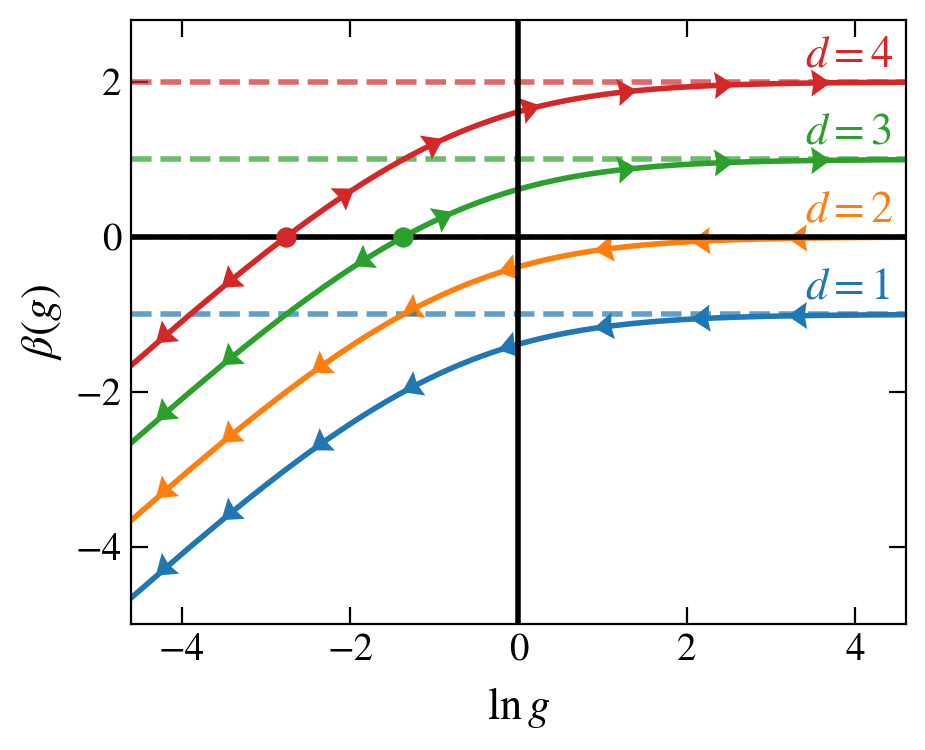

In [186]:

def envelope_ansatz(g, d=1, ad=1):
    return (d - 1) - (1 + g) * np.log(1 + 1/g)

colors_ls_cyc = itertools.cycle(colors_ls)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)


# axis[0].plot(z, ansatz(z, 1e6), label=r"$b=\infty$")
colors_ls_cyc = itertools.cycle(colors_ls)

# MAIN CURVES

pars2 = [4.692695889007306, 0.408438454954494563]
# pars2 = [5, 3.5]

r = tools.RootFinder(0, 1, 0.001)
roots = r.find(envelope_ansatz)
Sc = 1#roots[0]

print(roots)
s1min = 0.15 * Sc
s = np.linspace(s1min, 1, 1000)
fulldata = envelope_ansatz(s)


# inset = axis.inset_axes([0.34, 0.03, 0.62, 0.5]);  
xin1, xin2, yin1, yin2 = 0.7*Sc, 1.35 * Sc, envelope_ansatz(0.7*Sc), envelope_ansatz(1.75*Sc)

# s = np.linspace(xin1, xin2, 1000)
# axis.plot(s, (s - Sc) / Sc,      color='red',   ls=':', lw=1.5)
def envelope_erg(s, c):
    return -(1-s) * np.log( (1-s) / (c * s) )

ads = [1, 2/np.pi, 1, 1]
for iid, d in enumerate([1,2,3,4]):
    col = next(colors_ls_cyc)
    g = np.linspace(0.01, 100, 10000)
    y = envelope_ansatz(g, d=d, ad=ads[iid])
    axis.plot(np.log(g), y, color=col, zorder=2, lw=2)
    axis.axhline(y=d-2, color=col, lw=2, ls='--', alpha=0.7)
    axis.annotate(r"$d=%d$"%d, fontsize=16, xy=( np.log(0.3*max(g)), d-1.8), xycoords='data', color=col)
    
    points = [g.size // 10**4, g.size // 10**3.5, g.size // 10**3., g.size // 10**2.5, g.size // 10**2., g.size // 10**1.5, g.size // 10**1, g.size // 10**0.5]
    if d == 3:
        i1 = np.argmin(np.abs(y))
        points = [g.size // 10**4, g.size // 10**3.5, i1-8, i1+10, g.size // 10**1.5, g.size // 10**1, g.size // 10**0.5]
    for i2 in points:
        i1 = int(i2)
        xx = np.log(g)
        u = (xx[i1+1] - xx[i1]) if (y[i1] > 0) else (xx[i1] - xx[i1+1])
        v = (y[i1+1] - y[i1]) if (y[i1] > 0) else (y[i1] - y[i1+1])
        pos_x = (xx[i1] + u/2) 
        pos_y = (y[i1] + v/2)
        norm = np.sqrt(u**2+v**2)
        axis.quiver(pos_x, pos_y, u/norm, v/norm, angles="xy", zorder=-1, pivot="mid", linewidth=0, width=0.005, headwidth=7, color=col, lw=0)
    
    # g = np.linspace(0.1, 1, 1000)
    # y = envelope_ansatz(g, d=1)
    # ax.plot(np.log(g), y, color='red', ls='-', zorder=2, lw=2)
    # i1 = int( g.size // 4)
    # u = g[i1+1] - g[i1]
    # v = y[i1+1] - y[i1]
    # pos_x = g[i1] + u/2
    # pos_y = y[i1] + v/2
    # norm = np.sqrt(u**2+v**2)
    # axis.quiver(pos_x, pos_y, -u/norm, -v/norm, angles="xy", zorder=-1, pivot="mid", linewidth=0, width=0.005, headwidth=7, color='red', lw=0)
    
    if d > 2:
        r = tools.RootFinder(min(g), max(g), 0.02)
        roots = r.find(envelope_ansatz, d, ads[iid])
        print(roots)
        gc = roots[0]
        # idx = np.argmin(np.abs(y))
        # gc = g[idx]
        axis.scatter([np.log(gc)], [0], marker='o', s=40, color=col, zorder=3)

# plot_curves(axis)

fig_help.set_plot_elements(axis, ylabel=r"$\beta(g)$", xlabel=r"$\ln{g}$", font_size=14, set_legend=0, xscale='linear', yscale='linear')

# # CHANGE TICK PARAMS AND PLOT FRAME
# axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
# axis.set_yticks([])
# axis.set_yticklabels([])
# axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.axvline(x=0, ls='-', c='k', lw=2)
axis.axhline(y=0, ls='-', c='k', lw=2)

# axis.spines['top'].set_visible(False)
# axis.spines['right'].set_visible(False)
# axis.spines['bottom'].set_visible(False)
# axis.spines['left'].set_visible(False)

# # axis.arrow(0, 1.05*max(fulldata), 0.0, 0.02, shape='full', lw=0, length_includes_head=0, head_width=.025, color='k')
# # axis.arrow(1.04, 0, 0.003, 0, shape='full', lw=0, length_includes_head=0, head_width=.025, color='k')

# axis.quiver(0.0005, 1.4, 0.0, 0.01,angles="xy", zorder=-1, pivot="mid", linewidth=0, width=0.006, headwidth=6, color='k')
# axis.quiver(1.1, -0.0005, 0.01, 0, angles="xy", zorder=-1, pivot="mid", linewidth=0, width=0.006, headwidth=6, color='k')

axis.set_xlim(np.log(0.01), np.log(100), 1.13)
axis.set_ylim(None, 2.8)

# axis.annotate(r"ETH flow", fontsize=12, xy=(0.7, 0.45), xycoords='data', color='red', rotation=-28)


# axis.annotate(r"$\alpha\gtrsim\alpha_c$", fontsize=12, xy=(Sc-0.02, 0.35), xycoords='data', rotation=18, color='blue')
# axis.annotate(r"$\alpha\gg\alpha_c$", fontsize=12, xy=(Sc + 0.15, 1.), xycoords='data', rotation=-45, color='blue')
# axis.annotate(r"TWO-PARAMETER FLOW", fontsize=12, xy=(Sc + 0.2, 0.37), xycoords='data', rotation=-20, color='blue')

# axis.annotate(f"ONE-PARAMETER\n FLOW", fontsize=8, xy=(Sc + 0.25, 0.1), xycoords='data', rotation=0, color='red')

# axis.annotate(r"ETH", fontsize=14, xy=(0.95, -0.35), xycoords='data')
# axis.annotate(r"critical", fontsize=14, xy=(Sc+0.02, -0.3), xycoords='data')
# axis.annotate(r"$g$", fontsize=14, xy=(1.09, 0.15), xycoords='data')
# axis.annotate(r"$\beta_g$", fontsize=14, xy=(.03, 1.35), xycoords='data')

fig.savefig("Fig_Anderson_RGflow.pdf", bbox_inches = 'tight', pad_inches=0.02)